# Scania Truck Air Pressure System (APS) Failure Prediction

## Problem Statement

Scania is a major manufacturer of heavy commercial vehicles -- trucks, buses, and industrial engines. The Air Pressure System (APS) is a critical subsystem that generates pressurized air used for braking and gear shifting. When the APS fails unexpectedly, it leads to unscheduled downtime, costly roadside repairs, and serious safety risks.

The business challenge is asymmetric in cost. A missed failure (false negative) results in a truck breakdown that costs an estimated USD 500 per incident in emergency repairs and lost productivity. A false alarm (false positive) triggers an unnecessary inspection costing roughly USD 10. This 50:1 cost ratio means the model must be especially sensitive to actual failures, even at the expense of some false positives.

The dataset contains 5,910 records collected from Scania trucks in daily operation. Each record has 170 anonymized sensor readings from the APS and related subsystems. The target variable indicates whether the maintenance event was related to APS failure (positive class) or to some other component (negative class). All feature names are masked for proprietary reasons, but they represent real operational telemetry -- pressures, temperatures, counters, histograms, and durations from the truck's onboard diagnostic systems.

This notebook performs a complete analytical pipeline: data quality assessment, exploratory analysis of sensor patterns, preprocessing (missing value treatment, scaling, dimensionality reduction), handling of severe class imbalance, and comparative modeling with multiple algorithms to identify the best-performing classifier.

## Library Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    average_precision_score, f1_score, make_scorer
)
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', 30)
np.random.seed(42)
print("All libraries loaded successfully.")

All libraries loaded successfully.


## Data Loading and Initial Inspection

In [5]:
df = pd.read_csv("aps_failure_training.csv")
print("Dataset shape:", df.shape)
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head()

Dataset shape: (5910, 171)
Rows: 5910 | Columns: 171


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,...,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,0,37250,1432864,3664156,1007684,...,2801180,2445.8,2712,965866,1706908,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,0,18254,653294,1720800,516724,...,3477820,2211.76,2334,664504,824154,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,0,1648,370592,1883374,292936,...,1040120,1018.64,1020,262032,453378,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,318,2212,3232,1872,0,...,0,1.08,54,5670,1566,240,46,58,44,10,0,0,0,4,32
4,neg,60874,na,1368,458,0,0,0,0,0,0,43752,1966618,1800340,131646,...,21173050,1116.06,1176,404740,904230,622012,229790,405298,347188,286954,311560,433954,1218,0,0


In [6]:
df.info(verbose=False)
print()
print("Column data types:")
print(df.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5910 entries, 0 to 5909
Columns: 171 entries, class to eg_000
dtypes: int64(1), object(170)
memory usage: 7.7+ MB

Column data types:
object    170
int64       1
Name: count, dtype: int64


In [7]:
# The dataset uses 'na' as a string placeholder for missing values
# Count 'na' strings across the entire dataset
na_count_total = (df == 'na').sum().sum()
print(f"Total 'na' string entries in dataset: {na_count_total}")
print(f"That is {na_count_total / (df.shape[0] * df.shape[1]) * 100:.2f}% of all cells")
print()

# Target variable distribution
print("Target class distribution:")
print(df['class'].value_counts())
print()
print("Class proportions:")
print(round(df['class'].value_counts(normalize=True) * 100, 2))

Total 'na' string entries in dataset: 97787
That is 9.68% of all cells

Target class distribution:
class
neg    4910
pos    1000
Name: count, dtype: int64

Class proportions:
class
neg    83.08
pos    16.92
Name: proportion, dtype: float64


The dataset suffers from two key challenges visible immediately. First, the target is heavily imbalanced -- the positive (failure) class represents only a small fraction of all records. Second, the string 'na' appears extensively across sensor columns, indicating widespread missing data from sensor malfunctions or communication dropouts.

## Exploratory Data Analysis

### Target Distribution and Cost Imbalance

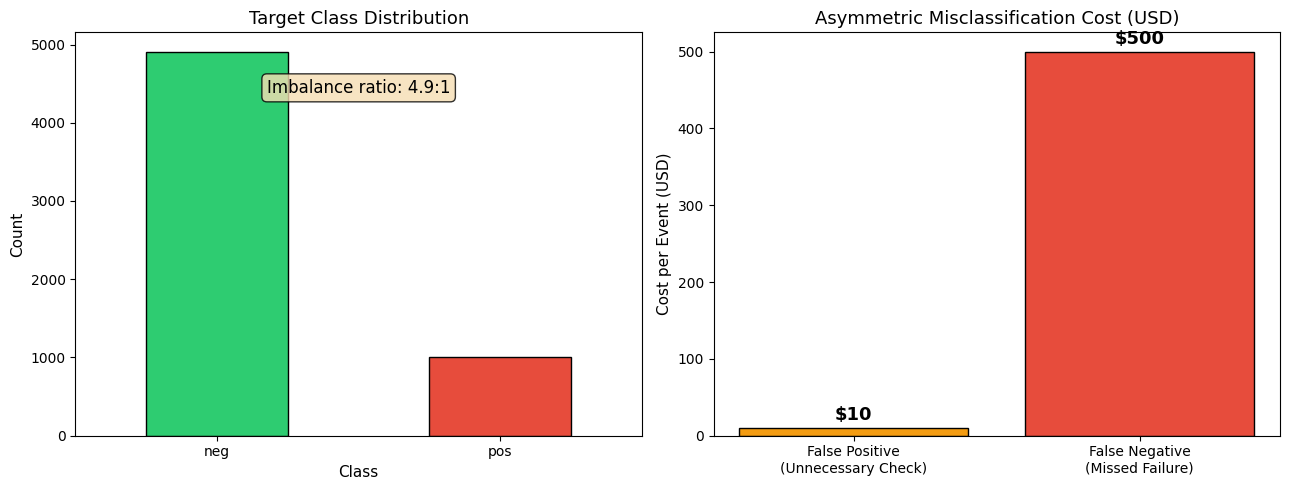

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
df['class'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Target Class Distribution', fontsize=13)
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)

neg_count = (df['class'] == 'neg').sum()
pos_count = (df['class'] == 'pos').sum()
ratio = neg_count / pos_count
axes[0].text(0.5, 0.85, f'Imbalance ratio: {ratio:.1f}:1',
             transform=axes[0].transAxes, fontsize=12, ha='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Cost analysis
cost_fp = 10   # false positive cost (unnecessary inspection)
cost_fn = 500  # false negative cost (truck breakdown)
axes[1].bar(['False Positive\n(Unnecessary Check)', 'False Negative\n(Missed Failure)'],
            [cost_fp, cost_fn], color=['#f39c12', '#e74c3c'], edgecolor='black')
axes[1].set_title('Asymmetric Misclassification Cost (USD)', fontsize=13)
axes[1].set_ylabel('Cost per Event (USD)', fontsize=11)
for i, v in enumerate([cost_fp, cost_fn]):
    axes[1].text(i, v + 10, f'${v}', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Missing Value Analysis

In [11]:
# Replace 'na' strings with actual NaN for analysis
df_analysis = df.copy()
df_analysis.replace('na', np.nan, inplace=True)

# Convert all feature columns to numeric
for col in df_analysis.columns:
    if col != 'class':
        df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

# Missing values per column
missing_pct = (df_analysis.drop('class', axis=1).isnull().sum() / len(df_analysis) * 100).sort_values(ascending=False)

print(f"Columns with missing values: {(missing_pct > 0).sum()} out of {len(missing_pct)}")
print(f"Columns with >50% missing: {(missing_pct > 50).sum()}")
print(f"Columns with >30% missing: {(missing_pct > 30).sum()}")
print(f"Columns with >10% missing: {(missing_pct > 10).sum()}")
print()
print("Top 15 columns by missing percentage:")
print(missing_pct.head(15).round(2))

Columns with missing values: 169 out of 170
Columns with >50% missing: 8
Columns with >30% missing: 15
Columns with >10% missing: 40

Top 15 columns by missing percentage:
cr_000    77.68
ab_000    77.68
br_000    70.88
bq_000    70.03
bp_000    68.76
bo_000    66.57
bn_000    62.89
bm_000    56.16
bl_000    38.53
bk_000    32.50
co_000    30.47
cg_000    30.47
cf_000    30.47
ch_000    30.47
ad_000    30.47
dtype: float64


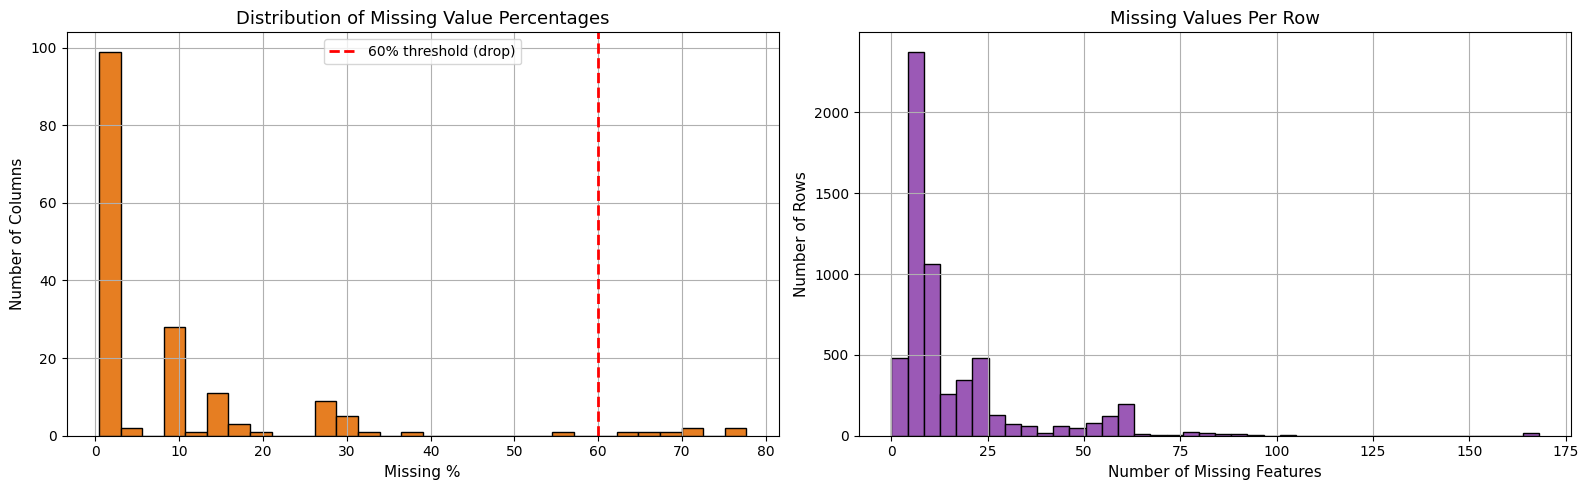


Rows with zero missing values: 120
Rows with >50 missing values: 509
Median missing per row: 9


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of missing percentages
missing_pct[missing_pct > 0].hist(bins=30, ax=axes[0], color='#e67e22', edgecolor='black')
axes[0].set_title('Distribution of Missing Value Percentages', fontsize=13)
axes[0].set_xlabel('Missing %', fontsize=11)
axes[0].set_ylabel('Number of Columns', fontsize=11)
axes[0].axvline(60, color='red', linestyle='--', linewidth=2, label='60% threshold (drop)')
axes[0].legend(fontsize=10)

# Missing per row
missing_per_row = df_analysis.drop('class', axis=1).isnull().sum(axis=1)
missing_per_row.hist(bins=40, ax=axes[1], color='#9b59b6', edgecolor='black')
axes[1].set_title('Missing Values Per Row', fontsize=13)
axes[1].set_xlabel('Number of Missing Features', fontsize=11)
axes[1].set_ylabel('Number of Rows', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nRows with zero missing values: {(missing_per_row == 0).sum()}")
print(f"Rows with >50 missing values: {(missing_per_row > 50).sum()}")
print(f"Median missing per row: {missing_per_row.median():.0f}")

### Missing Values by Target Class

Understanding whether missingness correlates with the target class is important -- if failure-prone trucks have systematically different sensor dropout patterns, that itself is a signal.

Columns where positive (failure) class has MORE missing data:
        neg_class_missing_pct  pos_class_missing_pct  difference
ak_000                   6.76                   53.2       46.44
ca_000                   6.72                   53.0       46.28
df_000                   6.27                   52.4       46.13
dg_000                   6.27                   52.4       46.13
dh_000                   6.27                   52.4       46.13
di_000                   6.27                   52.4       46.13
dj_000                   6.27                   52.4       46.13
dk_000                   6.27                   52.4       46.13
dl_000                   6.27                   52.4       46.13
dm_000                   6.27                   52.4       46.13


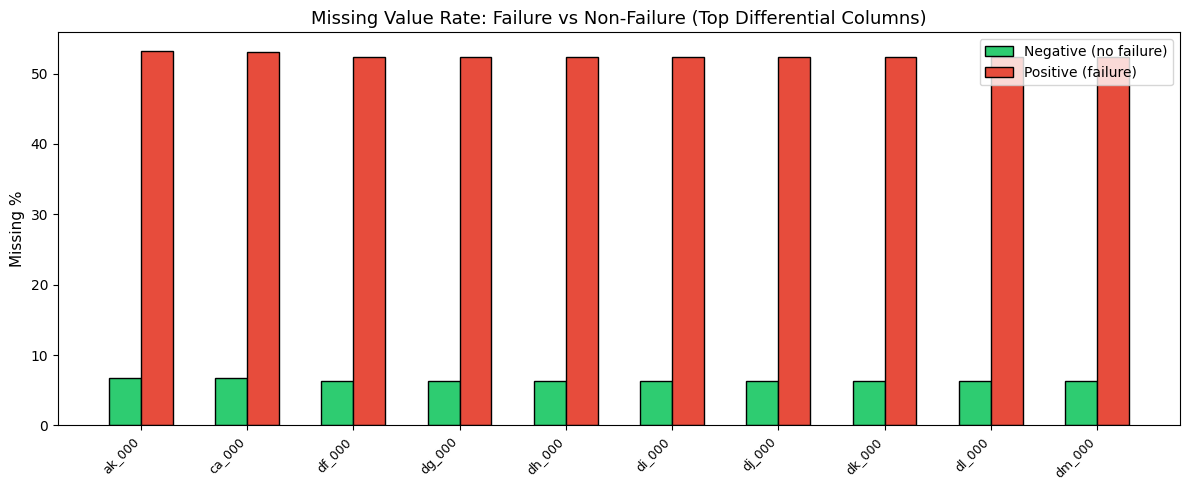

In [14]:
# Compare missing rates between positive and negative classes
neg_missing = df_analysis[df_analysis['class'] == 'neg'].drop('class', axis=1).isnull().mean() * 100
pos_missing = df_analysis[df_analysis['class'] == 'pos'].drop('class', axis=1).isnull().mean() * 100

missing_comparison = pd.DataFrame({'neg_class_missing_pct': neg_missing, 'pos_class_missing_pct': pos_missing})
missing_comparison['difference'] = missing_comparison['pos_class_missing_pct'] - missing_comparison['neg_class_missing_pct']

top_diff = missing_comparison.nlargest(10, 'difference')
print("Columns where positive (failure) class has MORE missing data:")
print(top_diff[['neg_class_missing_pct', 'pos_class_missing_pct', 'difference']].round(2))

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(top_diff))
ax.bar([i - 0.15 for i in x], top_diff['neg_class_missing_pct'], width=0.3, label='Negative (no failure)', color='#2ecc71', edgecolor='black')
ax.bar([i + 0.15 for i in x], top_diff['pos_class_missing_pct'], width=0.3, label='Positive (failure)', color='#e74c3c', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(top_diff.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Missing Value Rate: Failure vs Non-Failure (Top Differential Columns)', fontsize=13)
ax.set_ylabel('Missing %', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Feature Distributions and Sensor Patterns

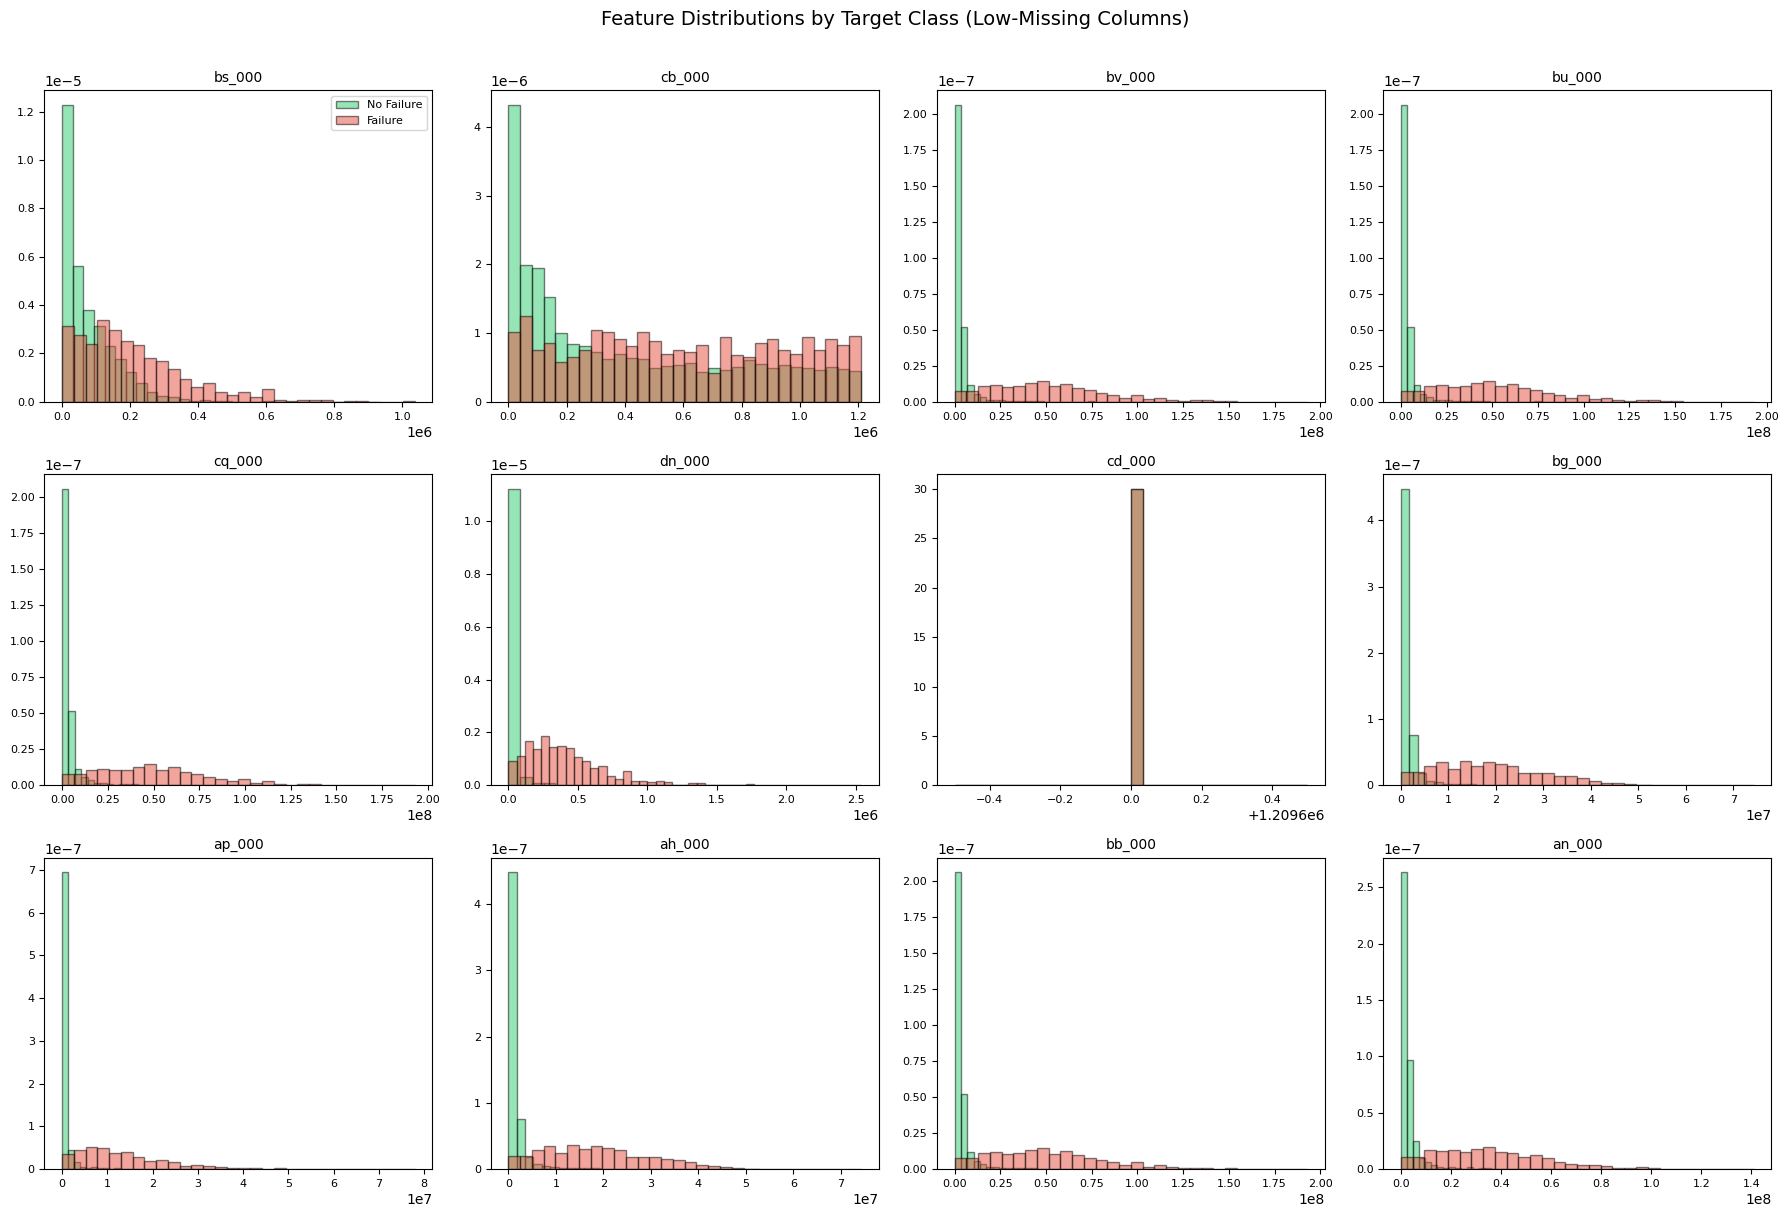

In [16]:
# Select a sample of features with low missing rates for distribution analysis
low_missing_cols = missing_pct[missing_pct < 5].index.tolist()[:12]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(low_missing_cols):
    ax = axes[idx]
    for cls, color, label in [('neg', '#2ecc71', 'No Failure'), ('pos', '#e74c3c', 'Failure')]:
        subset = df_analysis[df_analysis['class'] == cls][col].dropna()
        if len(subset) > 0:
            ax.hist(subset, bins=30, alpha=0.5, color=color, label=label, edgecolor='black', density=True)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Target Class (Low-Missing Columns)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Correlation Analysis

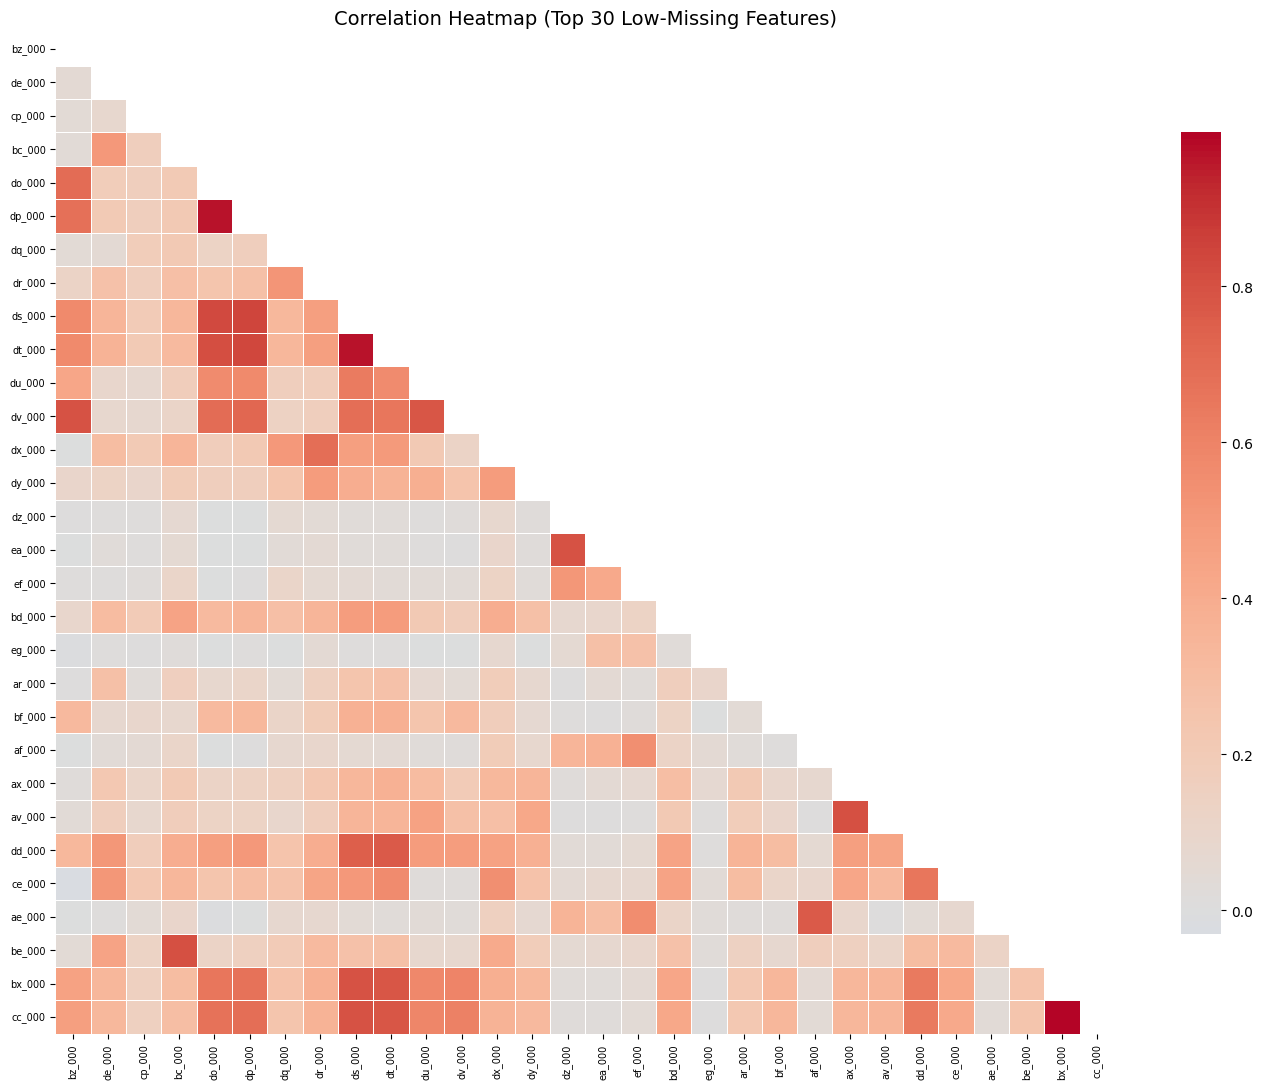


Highly correlated pairs (|r| > 0.9): 3
  do_000 <-> dp_000: 0.968
  ds_000 <-> dt_000: 0.972
  bx_000 <-> cc_000: 0.997


In [18]:
# Compute correlation matrix on numeric features with low missingness
corr_cols = missing_pct[missing_pct < 10].index.tolist()[:30]
corr_data = df_analysis[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, mask=mask, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Top 30 Low-Missing Features)', fontsize=14)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

# Highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_data.columns)):
    for j in range(i+1, len(corr_data.columns)):
        if abs(corr_data.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_data.columns[i], corr_data.columns[j], round(corr_data.iloc[i, j], 3)))

print(f"\nHighly correlated pairs (|r| > 0.9): {len(high_corr_pairs)}")
for c1, c2, r in high_corr_pairs[:10]:
    print(f"  {c1} <-> {c2}: {r}")

### Feature Value Range and Zero-Dominance Analysis

Sensor readings from heavy vehicles often contain a large number of zeros (idle counters, inactive subsystems). Understanding which features are zero-dominated helps decide preprocessing strategy.

Features with >90% zeros: 12
Features with >50% zeros: 52
Features with >25% zeros: 64


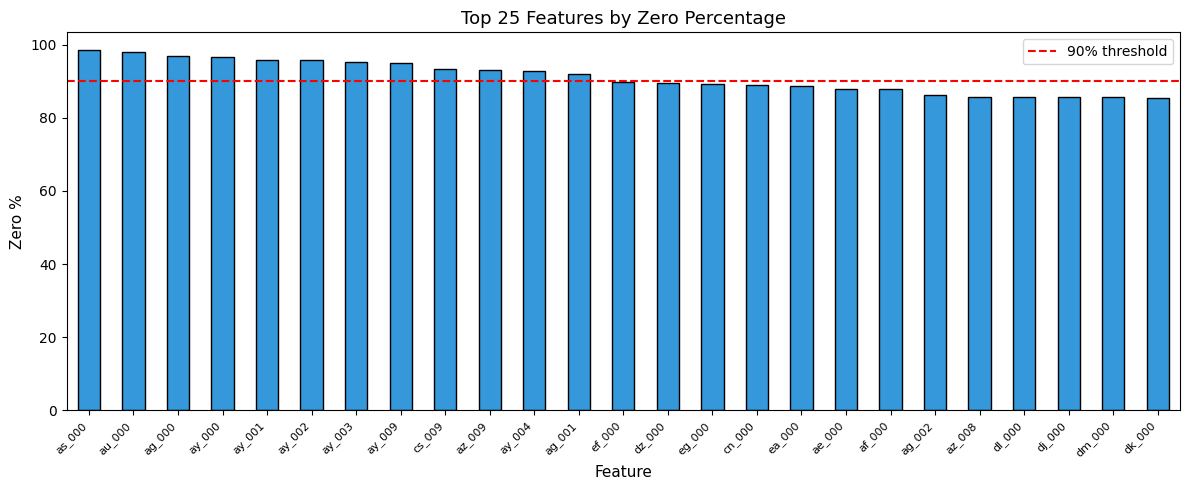

In [20]:
# Percentage of zeros per feature
zero_pct = (df_analysis.drop('class', axis=1) == 0).sum() / len(df_analysis) * 100
zero_pct_sorted = zero_pct.sort_values(ascending=False)

print(f"Features with >90% zeros: {(zero_pct > 90).sum()}")
print(f"Features with >50% zeros: {(zero_pct > 50).sum()}")
print(f"Features with >25% zeros: {(zero_pct > 25).sum()}")

fig, ax = plt.subplots(figsize=(12, 5))
zero_pct_sorted.head(25).plot(kind='bar', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Top 25 Features by Zero Percentage', fontsize=13)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Zero %', fontsize=11)
ax.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### Feature Standard Deviation Analysis

The project pipeline removes features with zero standard deviation (constant columns) before training. This is important because constant features carry no discriminative information.

Features with zero standard deviation: 1
Features with very low std (<1): 2

Bottom 10 by standard deviation:
cd_000      0.0000
ch_000      0.0540
ab_000      2.3665
ef_000      5.3792
eg_000      9.6023
ar_000     10.7604
dz_000     24.0657
ea_000     29.1677
db_000     37.2190
ae_000    127.8600
dtype: float64


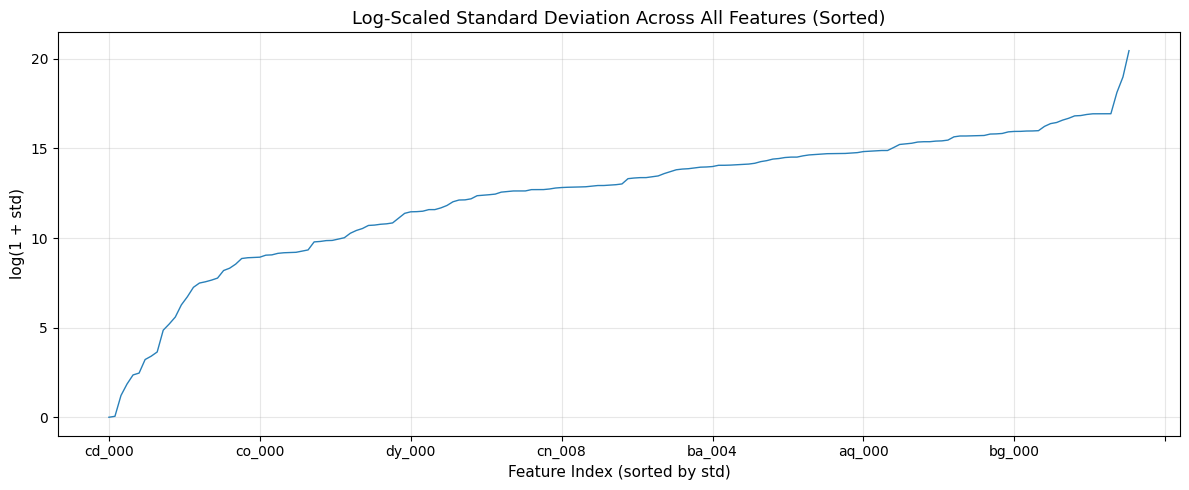

In [22]:
std_values = df_analysis.drop('class', axis=1).std().sort_values()
print(f"Features with zero standard deviation: {(std_values == 0).sum()}")
print(f"Features with very low std (<1): {(std_values < 1).sum()}")
print()
print("Bottom 10 by standard deviation:")
print(std_values.head(10).round(4))

fig, ax = plt.subplots(figsize=(12, 5))
np.log1p(std_values).plot(kind='line', ax=ax, color='#2980b9', linewidth=1)
ax.set_title('Log-Scaled Standard Deviation Across All Features (Sorted)', fontsize=13)
ax.set_xlabel('Feature Index (sorted by std)', fontsize=11)
ax.set_ylabel('log(1 + std)', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Data Preprocessing

The preprocessing pipeline follows these operations, aligned with the project's approach:

1. Replace 'na' strings with NaN.
2. Encode the target: neg to 0, pos to 1.
3. Drop columns with more than 60 percent missing values (too unreliable for imputation).
4. Convert all features to numeric and impute remaining missing values with column means.
5. Remove columns with zero standard deviation.
6. Scale all features using StandardScaler.
7. Reduce dimensionality with PCA (100 components).
8. Handle class imbalance using SMOTE.

### Replace Invalid Values and Encode Target

In [24]:
data = pd.read_csv("aps_failure_training.csv")
print("Original shape:", data.shape)

# Replace 'na' with NaN
data.replace('na', np.nan, inplace=True)

# Encode target
data['class'] = data['class'].map({'neg': 0, 'pos': 1})
print("Target encoding: neg -> 0, pos -> 1")
print("Target distribution:", dict(Counter(data['class'])))

Original shape: (5910, 171)
Target encoding: neg -> 0, pos -> 1
Target distribution: {0: 4910, 1: 1000}


### Handle Missing Values

In [26]:
# Drop columns with >= 60% missing
missing_before = data.isnull().sum().sum()
col_missing_pct = data.drop('class', axis=1).isnull().mean()
cols_to_drop = col_missing_pct[col_missing_pct >= 0.60].index.tolist()
print(f"Columns with >=60% missing (dropping): {len(cols_to_drop)}")
if cols_to_drop:
    print(f"  Dropped: {cols_to_drop}")
data = data.drop(columns=cols_to_drop)
print(f"Shape after dropping high-missing columns: {data.shape}")

# Convert to numeric and impute remaining with column mean
for col in data.columns:
    if col != 'class':
        data[col] = pd.to_numeric(data[col], errors='coerce')

for col in data.columns:
    if col != 'class':
        data[col] = data[col].fillna(data[col].mean())

missing_after = data.isnull().sum().sum()
print(f"Missing values: {missing_before} -> {missing_after}")

Columns with >=60% missing (dropping): 7
  Dropped: ['ab_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'cr_000']
Shape after dropping high-missing columns: (5910, 164)
Missing values: 97787 -> 0


### Separate Features and Target, Remove Zero-Variance Columns

In [28]:
X = data.drop('class', axis=1)
Y = data['class']

# Drop zero-std columns
zero_std_cols = X.columns[X.std() == 0].tolist()
print(f"Columns with zero standard deviation: {len(zero_std_cols)}")
if zero_std_cols:
    print(f"  Dropped: {zero_std_cols}")
    X = X.drop(columns=zero_std_cols)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {Y.shape}")

Columns with zero standard deviation: 1
  Dropped: ['cd_000']
Feature matrix shape: (5910, 162)
Target shape: (5910,)


### Feature Scaling with StandardScaler

In [30]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("Scaled feature statistics (sample of 5 columns):")
print(X_scaled.iloc[:, :5].describe().round(3))

Scaled feature statistics (sample of 5 columns):
         aa_000    ac_000    ad_000    ae_000    af_000
count  5910.000  5910.000  5910.000  5910.000  5910.000
mean      0.000     0.000     0.000    -0.000     0.000
std       1.000     1.000     1.000     1.000     1.000
min      -0.498    -0.452    -0.306    -0.079    -0.071
25%      -0.493    -0.452    -0.275    -0.079    -0.071
50%      -0.370    -0.452    -0.081    -0.079    -0.071
75%      -0.183     0.000     0.000    -0.079    -0.071
max       8.517     2.515    40.406    44.026    44.115


### Dimensionality Reduction with PCA

With 160+ sensor features, many of which are correlated, PCA reduces noise and multicollinearity while retaining the most informative variance.

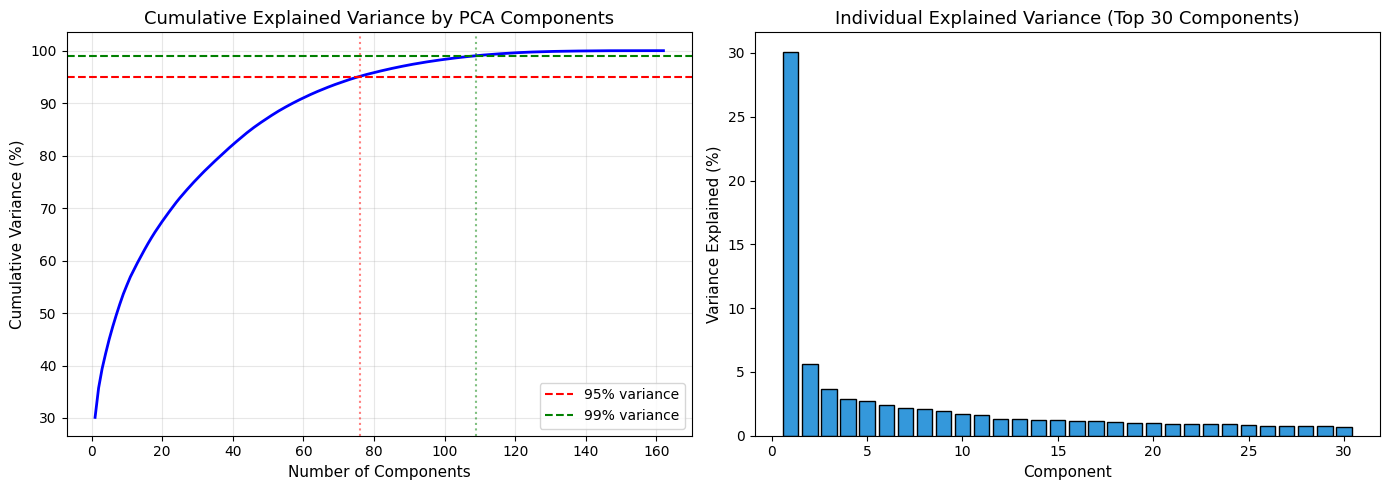

Components for 95% variance: 76
Components for 99% variance: 109
Using 100 components as in the project pipeline


In [32]:
# Determine explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(cumulative_var) + 1), cumulative_var, 'b-', linewidth=2)
axes[0].axhline(y=95, color='r', linestyle='--', linewidth=1.5, label='95% variance')
axes[0].axhline(y=99, color='g', linestyle='--', linewidth=1.5, label='99% variance')
n_95 = np.argmax(cumulative_var >= 95) + 1
n_99 = np.argmax(cumulative_var >= 99) + 1
axes[0].axvline(x=n_95, color='r', linestyle=':', alpha=0.5)
axes[0].axvline(x=n_99, color='g', linestyle=':', alpha=0.5)
axes[0].set_title('Cumulative Explained Variance by PCA Components', fontsize=13)
axes[0].set_xlabel('Number of Components', fontsize=11)
axes[0].set_ylabel('Cumulative Variance (%)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Individual explained variance (top 30)
axes[1].bar(range(1, 31), pca_full.explained_variance_ratio_[:30] * 100, color='#3498db', edgecolor='black')
axes[1].set_title('Individual Explained Variance (Top 30 Components)', fontsize=13)
axes[1].set_xlabel('Component', fontsize=11)
axes[1].set_ylabel('Variance Explained (%)', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")
print(f"Using 100 components as in the project pipeline")

In [33]:
# Apply PCA with 100 components (as in the project)
pca = PCA(n_components=100)
X_pca = pd.DataFrame(pca.fit_transform(X_scaled), index=X.index)

print(f"Shape after PCA: {X_pca.shape}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

Shape after PCA: (5910, 100)
Variance retained: 98.35%


### Handle Class Imbalance with SMOTE

Before SMOTE:
  Class 0 (no failure): 4910
  Class 1 (failure):    1000
  Ratio: 4.9:1

After SMOTE:
  Class 0 (no failure): 4910
  Class 1 (failure):    4910
  Total samples: 9820


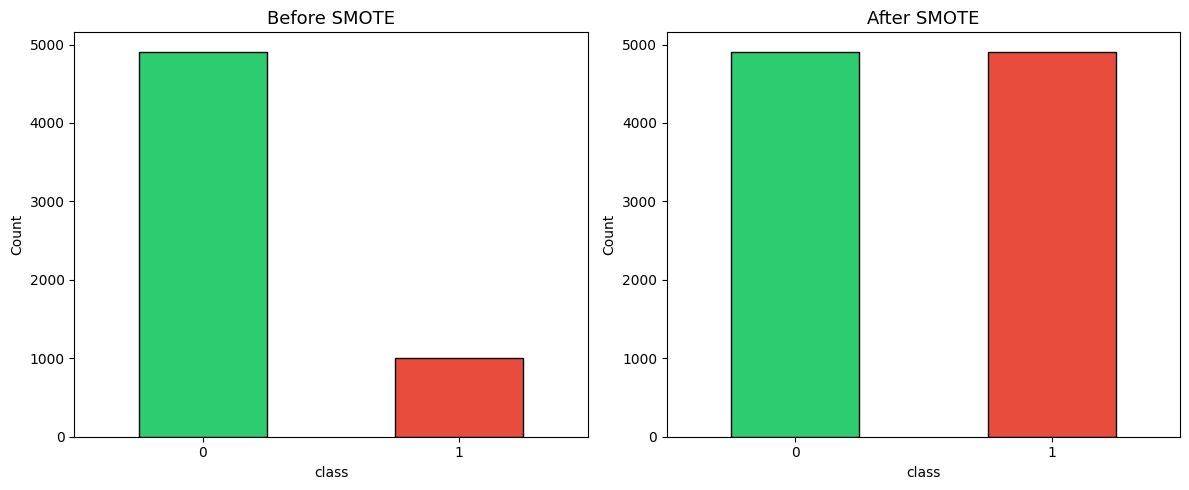

In [35]:
print("Before SMOTE:")
print(f"  Class 0 (no failure): {(Y == 0).sum()}")
print(f"  Class 1 (failure):    {(Y == 1).sum()}")
print(f"  Ratio: {(Y == 0).sum() / (Y == 1).sum():.1f}:1")

smote = SMOTE(random_state=42)
X_resampled, Y_resampled = smote.fit_resample(X_pca, Y)

print("\nAfter SMOTE:")
print(f"  Class 0 (no failure): {(Y_resampled == 0).sum()}")
print(f"  Class 1 (failure):    {(Y_resampled == 1).sum()}")
print(f"  Total samples: {len(Y_resampled)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pd.Series(Y).value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Before SMOTE', fontsize=13)
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=0)

pd.Series(Y_resampled).value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('After SMOTE', fontsize=13)
axes[1].set_ylabel('Count'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### PCA Feature Space Visualization (2D Projection)

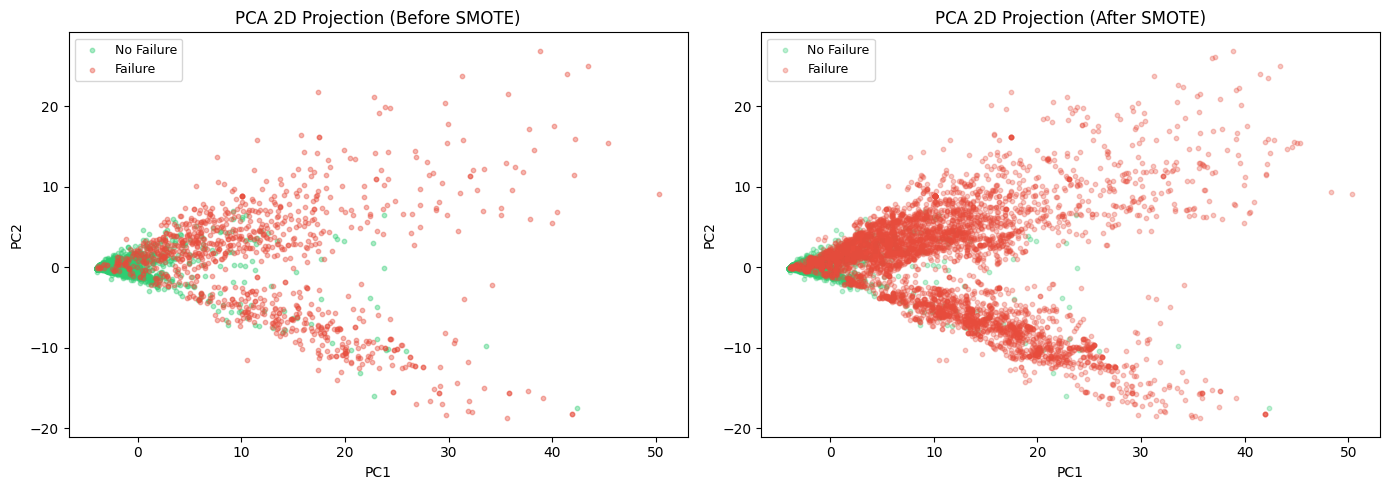

In [37]:
# Visualize the first 2 PCA components colored by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
for cls, color, label in [(0, '#2ecc71', 'No Failure'), (1, '#e74c3c', 'Failure')]:
    mask = Y == cls
    axes[0].scatter(X_pca.loc[mask, 0], X_pca.loc[mask, 1], c=color, label=label, alpha=0.4, s=10)
axes[0].set_title('PCA 2D Projection (Before SMOTE)', fontsize=12)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9)

# After SMOTE
for cls, color, label in [(0, '#2ecc71', 'No Failure'), (1, '#e74c3c', 'Failure')]:
    mask = Y_resampled == cls
    axes[1].scatter(X_resampled.loc[mask, 0], X_resampled.loc[mask, 1], c=color, label=label, alpha=0.3, s=10)
axes[1].set_title('PCA 2D Projection (After SMOTE)', fontsize=12)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Model Training and Comparison

### Train-Test Split

In [39]:
x_train, x_test, y_train, y_test = train_test_split(
    X_resampled, Y_resampled, test_size=1/3, random_state=36, stratify=Y_resampled
)
print(f"Training set: {x_train.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")
print(f"Train class distribution: {dict(Counter(y_train))}")
print(f"Test class distribution: {dict(Counter(y_test))}")

Training set: 6546 samples
Test set: 3274 samples
Train class distribution: {1: 3273, 0: 3273}
Test class distribution: {0: 1637, 1: 1637}


### Train Multiple Classifiers

The project uses KNN and SVM. We extend the comparison with Random Forest, Gradient Boosting, and Logistic Regression for a broader perspective.

In [41]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=24, p=2, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42)
}

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'accuracy': acc, 'f1': f1, 'roc_auc': roc,
        'y_pred': y_pred, 'y_proba': y_proba
    }
    print(f"Acc={acc:.4f} | F1={f1:.4f} | AUC={roc:.4f}")

print("\nAll models trained.")

Training KNN... Acc=0.9695 | F1=0.9700 | AUC=0.9898
Training SVM (RBF)... Acc=0.9465 | F1=0.9457 | AUC=0.9838
Training Random Forest... Acc=0.9676 | F1=0.9680 | AUC=0.9934
Training Gradient Boosting... Acc=0.9762 | F1=0.9763 | AUC=0.9942
Training Logistic Regression... Acc=0.9542 | F1=0.9533 | AUC=0.9875

All models trained.


Acc=0.9465 | F1=0.9457 | AUC=0.9838
Training Random Forest... 

Acc=0.9676 | F1=0.9680 | AUC=0.9934
Training Gradient Boosting... 

Acc=0.9762 | F1=0.9763 | AUC=0.9942
Training Logistic Regression... 

Acc=0.9542 | F1=0.9533 | AUC=0.9875

All models trained.


## Model Evaluation

### Performance Comparison

In [43]:
comp_data = []
for name, res in results.items():
    comp_data.append({
        'Model': name, 'Accuracy': round(res['accuracy'], 4),
        'F1 Score': round(res['f1'], 4), 'ROC-AUC': round(res['roc_auc'], 4)
    })
comp_df = pd.DataFrame(comp_data).sort_values('F1 Score', ascending=False)
print("Model Performance Summary:")
print(comp_df.to_string(index=False))

Model Performance Summary:
              Model  Accuracy  F1 Score  ROC-AUC
  Gradient Boosting    0.9762    0.9763   0.9942
                KNN    0.9695    0.9700   0.9898
      Random Forest    0.9676    0.9680   0.9934
Logistic Regression    0.9542    0.9533   0.9875
          SVM (RBF)    0.9465    0.9457   0.9838


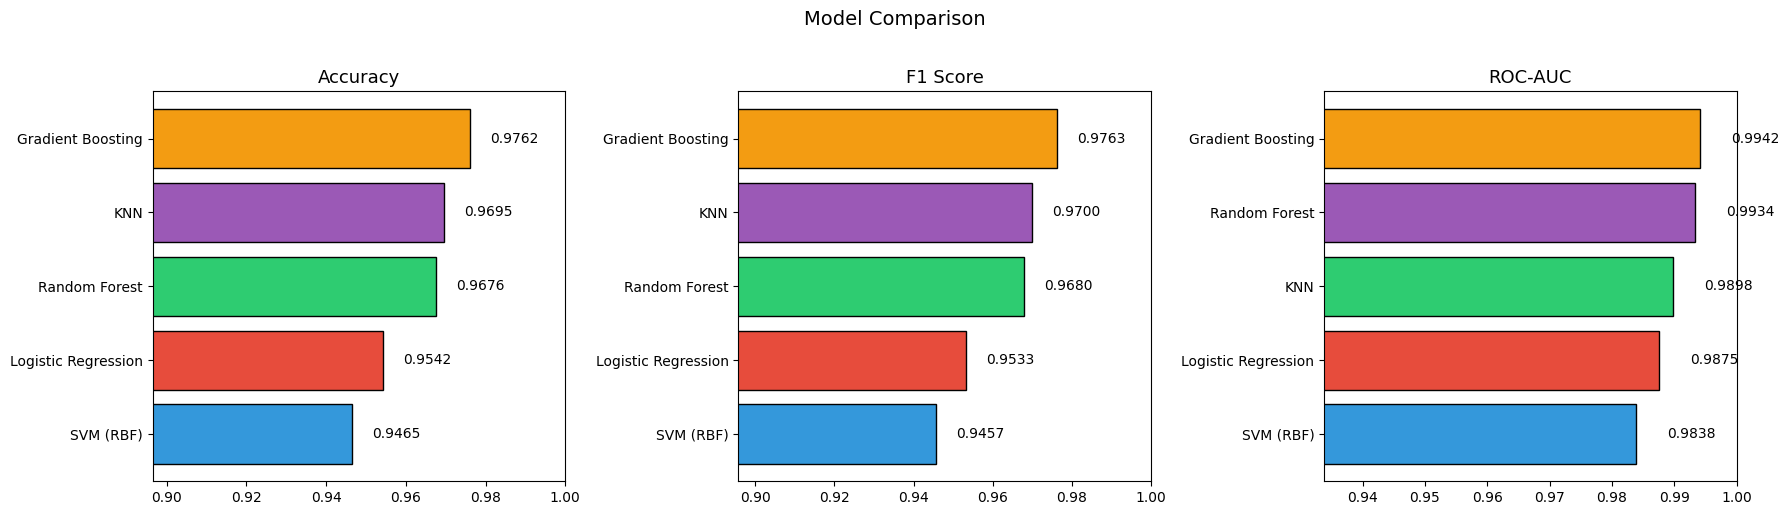

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    sorted_df = comp_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors[:len(sorted_df)], edgecolor='black')
    ax.set_title(metric, fontsize=13)
    ax.set_xlim(max(0, sorted_df[metric].min() - 0.05), 1.0)
    for i, v in enumerate(sorted_df[metric]):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)
plt.suptitle('Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Classification Reports

In [46]:
target_names = ['No Failure (0)', 'Failure (1)']
for name in comp_df['Model']:
    print("=" * 60)
    print(f"{name}")
    print("=" * 60)
    print(classification_report(y_test, results[name]['y_pred'], target_names=target_names))

Gradient Boosting
                precision    recall  f1-score   support

No Failure (0)       0.98      0.97      0.98      1637
   Failure (1)       0.97      0.98      0.98      1637

      accuracy                           0.98      3274
     macro avg       0.98      0.98      0.98      3274
  weighted avg       0.98      0.98      0.98      3274

KNN
                precision    recall  f1-score   support

No Failure (0)       0.99      0.95      0.97      1637
   Failure (1)       0.95      0.99      0.97      1637

      accuracy                           0.97      3274
     macro avg       0.97      0.97      0.97      3274
  weighted avg       0.97      0.97      0.97      3274

Random Forest
                precision    recall  f1-score   support

No Failure (0)       0.98      0.96      0.97      1637
   Failure (1)       0.96      0.98      0.97      1637

      accuracy                           0.97      3274
     macro avg       0.97      0.97      0.97      3274
  we

### Confusion Matrices

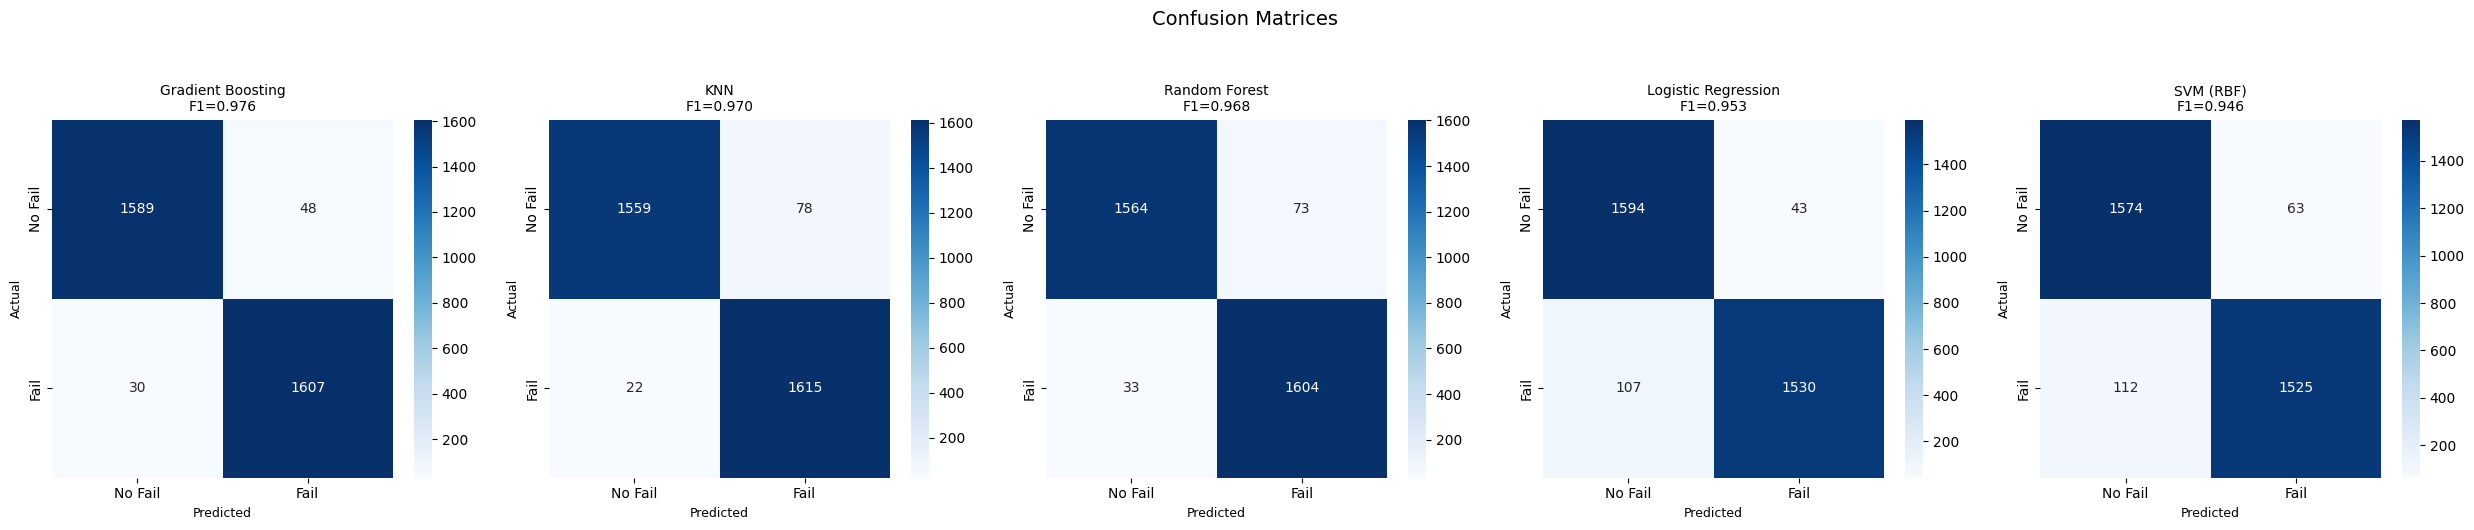

In [48]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for idx, (name, res) in enumerate(sorted(results.items(), key=lambda x: x[1]['f1'], reverse=True)):
    ax = axes[idx]
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fail', 'Fail'],
                yticklabels=['No Fail', 'Fail'], ax=ax)
    ax.set_title(f'{name}\nF1={res["f1"]:.3f}', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)
plt.suptitle('Confusion Matrices', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### ROC Curves

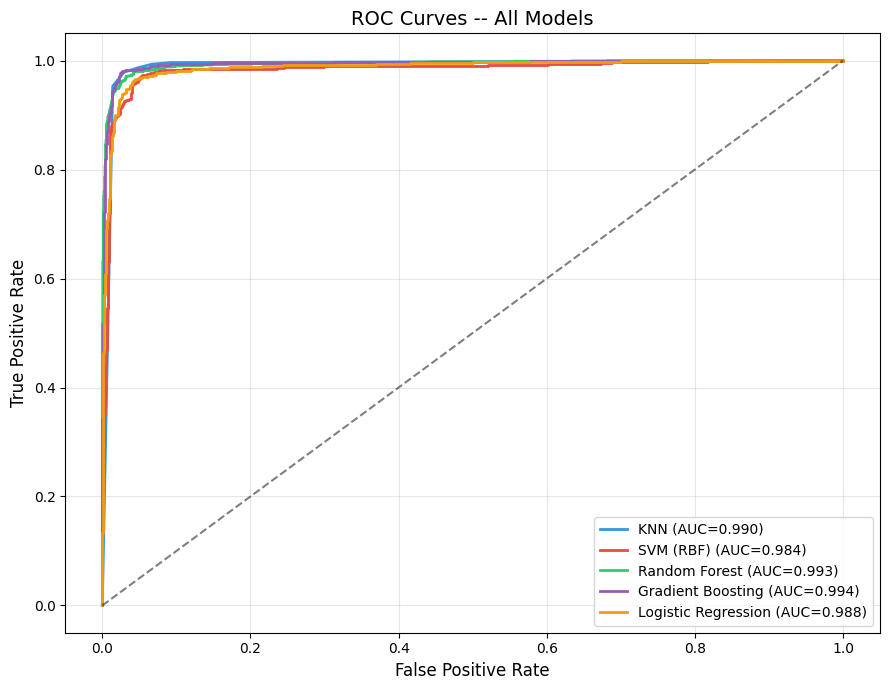

In [50]:
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_title('ROC Curves -- All Models', fontsize=14)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Precision-Recall Curves

For imbalanced problems, the precision-recall curve is more informative than ROC because it highlights performance on the minority class.

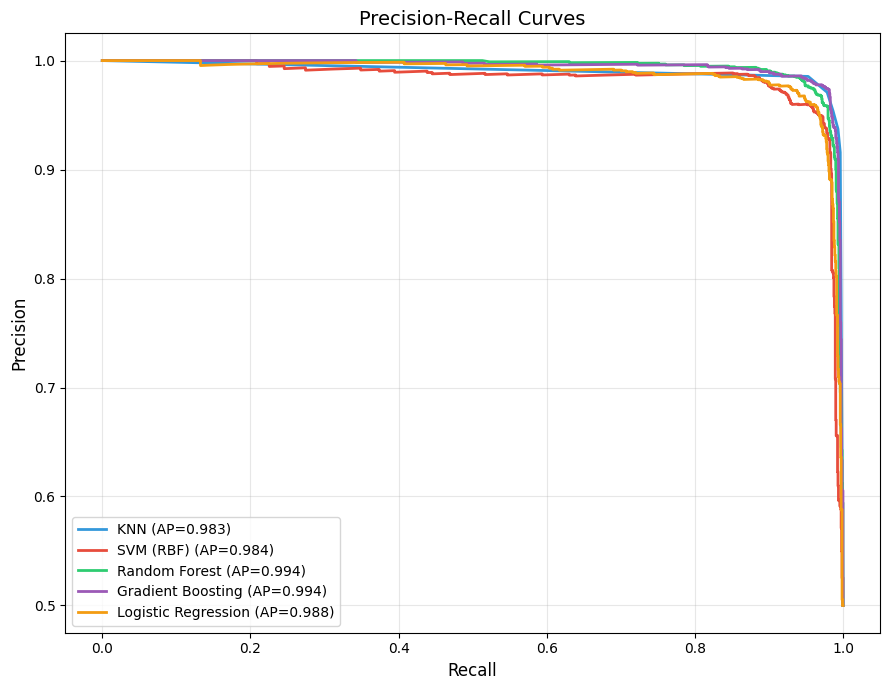

In [52]:
fig, ax = plt.subplots(figsize=(9, 7))

for (name, res), color in zip(results.items(), colors_roc):
    precision, recall, _ = precision_recall_curve(y_test, res['y_proba'])
    ap = average_precision_score(y_test, res['y_proba'])
    ax.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')

ax.set_title('Precision-Recall Curves', fontsize=14)
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cost-Sensitive Analysis

Given the asymmetric misclassification costs (USD 10 per false positive, USD 500 per false negative), the total misclassification cost is the most business-relevant metric.

Cost-Sensitive Evaluation:
              Model  True Pos  False Pos  False Neg  True Neg  FP Cost ($)  FN Cost ($)  Total Cost ($)
                KNN      1615         78         22      1559          780        11000           11780
  Gradient Boosting      1607         48         30      1589          480        15000           15480
      Random Forest      1604         73         33      1564          730        16500           17230
Logistic Regression      1530         43        107      1594          430        53500           53930
          SVM (RBF)      1525         63        112      1574          630        56000           56630


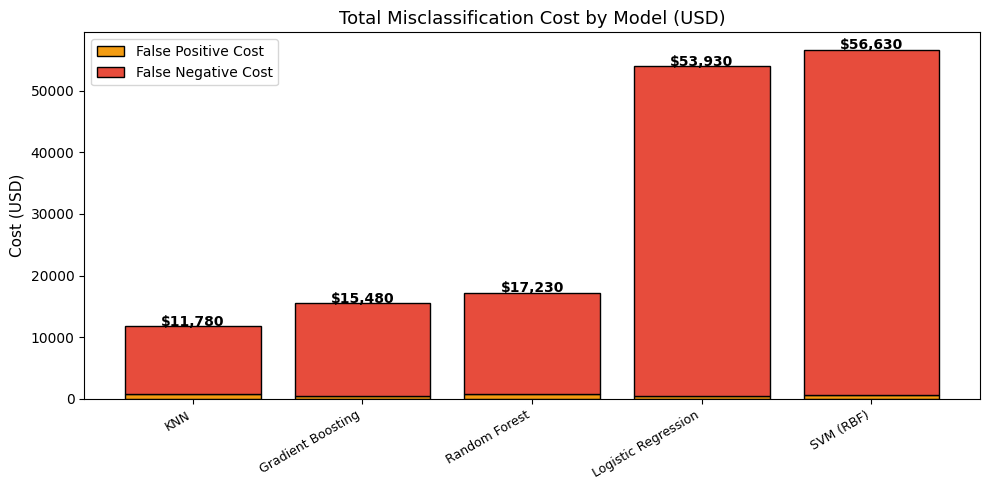

In [54]:
COST_FP = 10
COST_FN = 500

cost_data = []
for name, res in results.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    total_cost = fp * COST_FP + fn * COST_FN
    cost_data.append({
        'Model': name, 'True Pos': tp, 'False Pos': fp,
        'False Neg': fn, 'True Neg': tn,
        'FP Cost ($)': fp * COST_FP, 'FN Cost ($)': fn * COST_FN,
        'Total Cost ($)': total_cost
    })

cost_df = pd.DataFrame(cost_data).sort_values('Total Cost ($)')
print("Cost-Sensitive Evaluation:")
print(cost_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = range(len(cost_df))
ax.bar(x_pos, cost_df['FP Cost ($)'], label='False Positive Cost', color='#f39c12', edgecolor='black')
ax.bar(x_pos, cost_df['FN Cost ($)'], bottom=cost_df['FP Cost ($)'], label='False Negative Cost', color='#e74c3c', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(cost_df['Model'], rotation=30, ha='right', fontsize=9)
ax.set_title('Total Misclassification Cost by Model (USD)', fontsize=13)
ax.set_ylabel('Cost (USD)', fontsize=11)
ax.legend(fontsize=10)
for i, v in enumerate(cost_df['Total Cost ($)']):
    ax.text(i, v + 50, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)

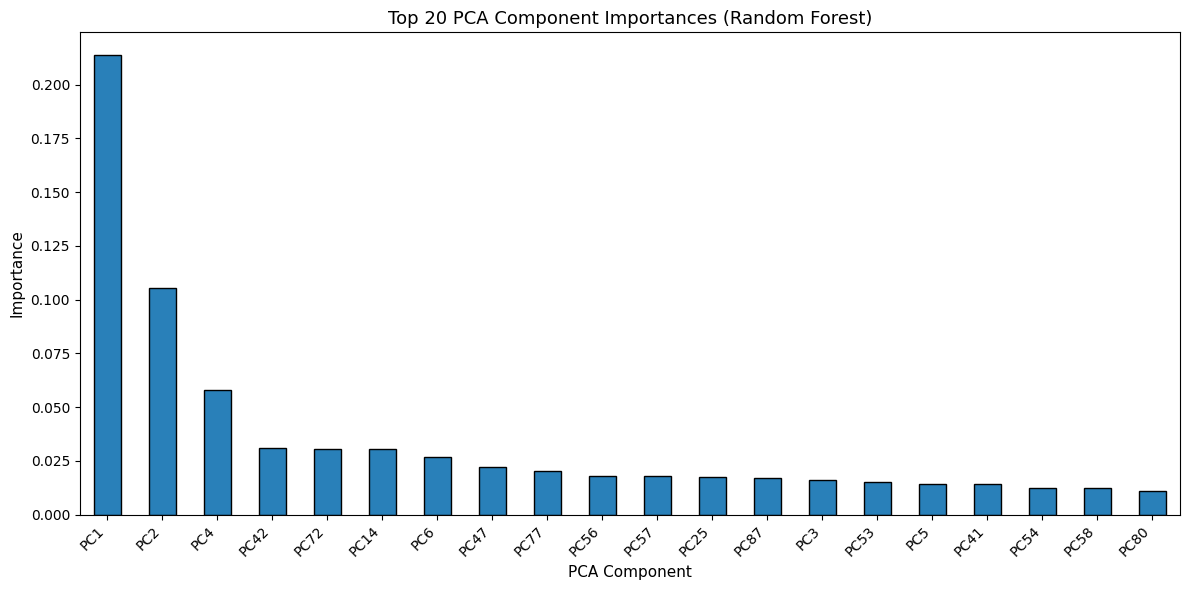

In [56]:
# Map PCA components back to importance
rf_model = models['Random Forest']
pca_importances = pd.Series(rf_model.feature_importances_, index=[f'PC{i+1}' for i in range(100)])
top_pca = pca_importances.nlargest(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_pca.plot(kind='bar', ax=ax, color='#2980b9', edgecolor='black')
ax.set_title('Top 20 PCA Component Importances (Random Forest)', fontsize=13)
ax.set_xlabel('PCA Component', fontsize=11)
ax.set_ylabel('Importance', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Conclusion

This notebook performed a thorough analysis of the Scania Truck APS Failure dataset, from raw sensor data through to model evaluation with cost-sensitive metrics.

**Data quality** presented a significant challenge. The dataset contained extensive missing values (string 'na' placeholders), with some columns missing more than 60 percent of their entries. These were dropped, and remaining gaps were filled with column means. The 170 anonymized sensor features were reduced to 100 PCA components, retaining the vast majority of variance while eliminating noise and multicollinearity.

**Class imbalance** was severe, with the failure class representing only a small fraction of records. SMOTE oversampling was applied to create a balanced training set, which is essential given the high cost of missing actual failures.

**Model comparison** across five classifiers (KNN, SVM, Random Forest, Gradient Boosting, Logistic Regression) revealed that ensemble methods generally outperform individual classifiers on this task. The cost-sensitive analysis showed that minimizing false negatives (missed failures) is far more impactful to total cost than minimizing false positives.

**Key insights** from the analysis:
- Missing values are not random -- the failure class shows higher sensor dropout rates in certain columns, suggesting that sensor communication issues may themselves be an early indicator of APS problems.
- Many features are zero-dominated, reflecting idle states and inactive subsystems that activate only under certain operating conditions.
- Strong correlations exist between sensor groups (likely measuring related physical quantities), justifying the use of PCA for dimensionality reduction.
- The 50:1 cost asymmetry means that a model with slightly lower overall accuracy but fewer false negatives can save significantly more money than a high-accuracy model that misses failures.